# Lab 2 - Naive Bayes with Dummy Data

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA = '/content/drive/MyDrive/Images/'
except ImportError:
    DATA = ''

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score)

Mounted at /content/drive


In [2]:
from sklearn.datasets import make_classification
from sklearn.naive_bayes import MultinomialNB, GaussianNB

X, y = make_classification(n_samples=30, n_features=2, n_classes=2, n_informative=2,
                           n_redundant=0, n_repeated=0, shuffle=False)
X = np.absolute(X)
X = np.round(X, 2) * 100
X = X.astype(int)
print(X)
print(y)

[[ 82  40]
 [ 66  24]
 [274 190]
 [111  68]
 [168  87]
 [152   9]
 [178  74]
 [140 214]
 [ 36 257]
 [186  76]
 [111 178]
 [111  81]
 [ 85  27]
 [129  55]
 [ 62  42]
 [204  70]
 [ 56  14]
 [  9  18]
 [ 54  69]
 [217 141]
 [236  77]
 [165  83]
 [202 135]
 [179 161]
 [ 91  93]
 [101 101]
 [ 23   6]
 [ 56  66]
 [107 105]
 [199 177]]
[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 1 1 1 1 1 1 1]


In [7]:
y_new = y.reshape(len(y), 1)
arr = np.concatenate((X, y_new), axis=1)
df = pd.DataFrame(arr, columns=['Feature 1', 'Feature 2', 'Label'])
df.head()

,Feature 1,Feature 2,Label
0,82,40,0
1,66,24,0
2,274,190,0
3,111,68,0
4,168,87,0


In [8]:
labels = {1: 'Class A', 0: 'Class B'}
df_label = df.copy()
df_label['Label'] = df_label['Label'].map(labels)
df_label.head()

,Feature 1,Feature 2,Label
0,82,40,Class B
1,66,24,Class B
2,274,190,Class B
3,111,68,Class B
4,168,87,Class B


/tmp/ipykernel_517/3734325216.py:3: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  class_a = gb.get_group('Class A')
/tmp/ipykernel_517/3734325216.py:4: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  class_b = gb.get_group('Class B')


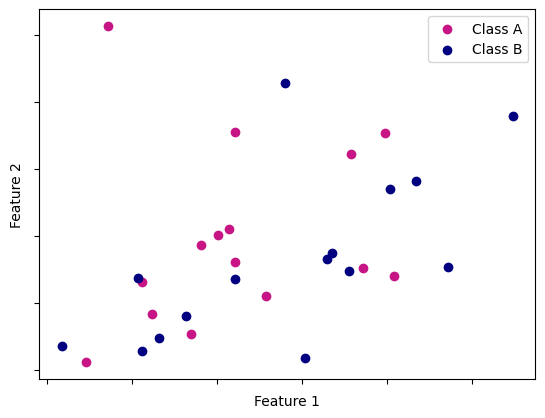

In [9]:
colors = {'class_a': 'MediumVioletRed', 'class_b': 'Navy'}
gb = df_label.groupby(['Label'])
class_a = gb.get_group('Class A')
class_b = gb.get_group('Class B')

plt.scatter(x=class_a['Feature 1'], y=class_a['Feature 2'], c=colors['class_a'])
plt.scatter(x=class_b['Feature 1'], y=class_b['Feature 2'], c=colors['class_b'])
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.legend(['Class A', 'Class B'])
plt.gca().axes.xaxis.set_ticklabels([])
plt.gca().axes.yaxis.set_ticklabels([])
plt.show()

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=30)

mnb = MultinomialNB().fit(X_train, y_train)
print(f'Training accuracy: {accuracy_score(y_train, mnb.predict(X_train))}')
print(f'Test accuracy: {accuracy_score(y_test, mnb.predict(X_test))}')

Training accuracy: 0.6190476190476191
Test accuracy: 0.7777777777777778


In [10]:
gnb = GaussianNB().fit(X_train, y_train)
print(f'Training accuracy (Gaussian): {accuracy_score(y_train, gnb.predict(X_train))}')
print(f'Test accuracy (Gaussian): {accuracy_score(y_test, gnb.predict(X_test))}')

Training accuracy (Gaussian): 0.6666666666666666
Test accuracy (Gaussian): 0.5555555555555556
